In [57]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add

from groq import Groq

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message

#### query expansion(parallel execution)

In [58]:
class State(BaseModel):
    expanded_query: List[str]=[]
    retrieved_context: Annotated[List[str],add]=[]  
    question_relevant:bool=False
    initial_query: str=""
    answer:str=""
    query:str=""
    k:int=20

#### query expansion/rewriting node

In [59]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(..., description="List of expanded queries derived from the original query.")

In [60]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider":"groq","ls_model_name":"qwen3-32b"}
)
def query_expand_node(state: State) -> dict:

    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
-Be as Concise as possible , do not make synonyms, one statement per piece of context.
<Question>
{{ query }}
</Question>
"""
    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider("groq/llama-3.3-70b-versatile")

    response, raw_response = client.create_with_completion(
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )

    return {
        "expanded_query": response.expanded_query
    }

In [61]:
def query_expand_conditional_edges(state: State):
    send_messages = []
    
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )
    
    return send_messages

In [62]:
import json
import os
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError

HF_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
HF_API_TOKEN = os.environ.get('HF_API_TOKEN')  # set your Hugging Face token, e.g., os.environ.get('HF_API_TOKEN')


def _mean_pool_embedding(raw_embedding):
    if not raw_embedding:
        raise ValueError("Hugging Face API returned an empty embedding.")

    if isinstance(raw_embedding[0], (int, float)):
        return [float(value) for value in raw_embedding]

    if isinstance(raw_embedding[0], list):
        token_count = len(raw_embedding)
        vector_size = len(raw_embedding[0])
        pooled = [0.0] * vector_size

        for token_vector in raw_embedding:
            if len(token_vector) != vector_size:
                raise ValueError("Inconsistent token vector dimensions in HF embedding response.")
            for idx, value in enumerate(token_vector):
                pooled[idx] += float(value)

        return [value / token_count for value in pooled]

    raise ValueError("Unexpected Hugging Face embedding response format.")

@traceable(name="embed query",run_type="embedding",metadata={"ls_provider":"hugging-face","ls_model_name":"sentence-transformers/all-MiniLM-L6-v2"})
def get_embedding(text, model_name: str | None = None):
    selected_model = model_name or HF_EMBEDDING_MODEL
    endpoint = (
        "https://router.huggingface.co/hf-inference/models/"
        f"{selected_model}/pipeline/feature-extraction"
    )
    payload = json.dumps({"inputs": text, "normalize": True}).encode("utf-8")

    headers = {"Content-Type": "application/json"}
    if HF_API_TOKEN:
        headers["Authorization"] = f"Bearer {HF_API_TOKEN}"

    request = Request(endpoint, data=payload, headers=headers, method="POST")

    try:
        with urlopen(request, timeout=60) as response:
            response_data = json.loads(response.read().decode("utf-8"))
    except HTTPError as exc:
        message = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(
            f"Hugging Face embedding API request failed ({exc.code}): {message}"
        ) from exc
    except URLError as exc:
        raise RuntimeError(f"Could not reach Hugging Face embedding API: {exc}") from exc

    if isinstance(response_data, dict) and response_data.get("error"):
        raise RuntimeError(f"Hugging Face embedding API error: {response_data['error']}")

    if isinstance(response_data, list) and len(response_data) == 1:
        return _mean_pool_embedding(response_data[0])

    return _mean_pool_embedding(response_data)



@traceable(name="retrieve data",run_type="retriever")
def retrieve_node(state: State) -> dict:
    qdrant_client=QdrantClient(url="http://localhost:6333")

    query_embedding=get_embedding(state["query"])

    search_result=qdrant_client.query_points(
        collection_name="amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="all-MiniLM-L6-v2",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state["query"],
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=state["k"],
    )

    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]
    for search_result in search_result.points:
        retrieved_context_ids.append(search_result.payload["parent_asin"])
        retrieved_context.append(search_result.payload["description"])
        retrieved_context_ratings.append(search_result.payload["average_rating"])
        similarity_scores.append(search_result.score)

    formatted_context=""
    for id , chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context+=f"-ID: {id},rating: {rating},description: {chunk} \n"


    return {
        "retrieved_context": [formatted_context]
    }


In [63]:
#### aggregator node to combine retrieved contexts
class AggregatorResponse(BaseModel):
    answer: str = Field(..., description="Final answer generated by the aggregator node based on the retrieved contexts.")

In [64]:
@traceable(
        name="aggregator_node",
        run_type="llm",
        metadata={"ls_provider":"groq","ls_model_name":"llama-3.3-70b-versatile"}
)
def aggregator_node(state: State) -> dict:
    preprocessed_context="\n".join(state.retrieved_context)
    prompt_template =  """You are a shopping assistant that can answer questions about the products in stock.

    You will be given a question and a list of context.

    Instructions:
    
    - You need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

    Context:
    {{ preprocessed_context }}

    Question:
    {{ question }}
"""
    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider("groq/llama-3.3-70b-versatile")

    response, raw_response = client.create_with_completion(
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )

    return {
        "answer": response.answer
    }

#### user intent router node

In [65]:
class IntentRouterResponse(BaseModel):
   question_relevant: bool
   answer: str

In [66]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "groq", "ls_model_name": "llama-3.3-70b-versatile"}
)
def intent_router_node(state: State):
    """
    Routes user queries by determining if they are relevant to products in stock.
    
    Args:
        state: Contains the initial_query from the user
        
    Returns:
        Dictionary with question_relevant flag and optional answer
    """
    
    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to classify it into relevant or not relevant.
- If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
- If the question is relevant, return True in field "question_relevant" and set "answer" to "".
- You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.

<Question>
{{ query }}
</Question>"""

    template = Template(prompt_template)
    
    prompt = template.render(
        query=state.initial_query
    )
    
    client = instructor.from_provider("groq/llama-3.3-70b-versatile")
    
    response, raw_response = client.create_with_completion(
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    
    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [67]:
def intent_router_conditional_edges(state: State):
    if state.question_relevant:
        return "query_expand_node"
    else:
        return "end"

In [68]:
workflow = StateGraph(State)
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
workflow.add_conditional_edges(
    "intent_router_node", intent_router_conditional_edges,
    {
        "query_expand_node": "query_expand_node",
        "end": END

    }
)
workflow.add_edge("retrieve_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph=workflow.compile()

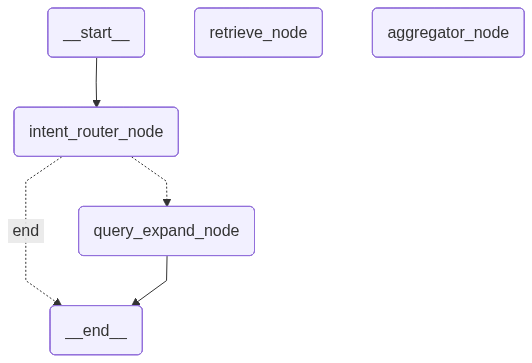

In [69]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [71]:
initial_state = {
    "initial_query": "CAN i get a kids album for my kid and a rock album for me and waterproof speaker for our party next week?"
}
result=graph.invoke(initial_state)


In [72]:
result

{'expanded_query': ['kids music albums',
  'rock music albums',
  'waterproof speakers'],
 'retrieved_context': ['-ID: B0C2B869LV,rating: 4.6,description: Rise And Fall, Rage And Grace [15th Anniversary Edition] [LP + 7" Single] 15th Anniversary Edition of The Offspring\'s 2008 album - Rise And Fall, Rage And Grace - featuring a bonus 7" single on translucent red vinyl with two new live tracks from Hellfest, a newly reimagined album cover and art lithographs for each song. The album and 7" single includes their most popular streaming song, "You\'re Gonna Go Far, Kid." Limited Edition. \n-ID: B09TJ4L1GG,rating: 4.8,description: Sings Gunfighter Ballads and Trail Songs (CLEAR WITH BLACK "GUNSMOKE" SWIRL VINYL) Real Gone Music is proud to present the original mono version of what most folks consider to be the single greatest postwar album of Western music, Marty Robbins\' 1959 record Gunfighter Ballads and Trail Songs. Everything about this album is iconic, from its "quick draw" cover art

In [73]:
initial_state = {
    "initial_query": "whats the weather today?"
}
result=graph.invoke(initial_state)
result

{'retrieved_context': [],
 'question_relevant': False,
 'initial_query': 'whats the weather today?',
 'answer': "This question is not relevant because it's about the weather, not about our products in stock. For questions about our products, I'd be happy to help."}